# Showing what FFT does
This notebook is supposed to illustrate the effects of FFT on landscapes.
It does that by showing which features persist when selecting a certain frequency range from a landscape tile’s FFT magnitude.

In [1]:
import numpy as np
import pyfftw
import cv2
import matplotlib.pyplot as plt
import common
from sklearn.preprocessing import MinMaxScaler
import subprocess
import ffmpeg
import numpy as np
from scipy.ndimage import gaussian_filter

In [2]:
NUMBER_OF_SAMPLES = 17
SIDE_LENGTH_FFT = 23

In [3]:
def gaussian_filter_weighted(input: np.ndarray, sigma):
    # Gültigkeitsmaske: überall 1
    valid = np.ones_like(input)

    num = gaussian_filter(input, sigma=sigma, mode="constant", cval=0)
    den = gaussian_filter(valid, sigma=sigma, mode="constant", cval=0)

    ergebnis = num / den

    return ergebnis

In [4]:
def normalize(array):
    factor = np.max(array) - np.min(array)
    if factor == 0: return np.zeros((1))
    return (array - np.min(array)) / factor

[ WARN:0@1.764] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@1.764] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@1.764] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@1.764] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34736 (0x87b0) encountered
[ WARN:0@1.764] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered


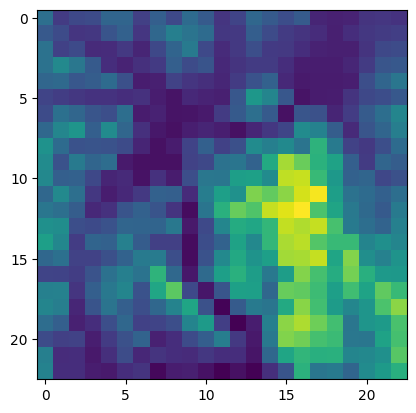

In [5]:
image_source_path = "/Users/scharnagl/Documents/GitHub/geospatial-landscape-clustering-by-fft/documentation/Representative_Samples/16_bit_heightmaps/schottland_ben_nevis_2_aeqd_-4.9750_56.7600_ps.tif"

image_source_path = "/Users/scharnagl/Documents/GitHub/geospatial-landscape-clustering-by-fft/documentation/Representative_Samples/16_bit_heightmaps/italy_sample_tile_aeqd_11.2955_42.9107.tif"

image_pixels = cv2.imread(image_source_path, cv2.IMREAD_ANYDEPTH)
#image_pixels = (image_pixels - np.min(image_pixels)) / (np.max(image_pixels) - np.min(image_pixels))

# CAUTION resize
image_pixels = cv2.resize(image_pixels, (23,23), interpolation=cv2.INTER_CUBIC)

plt.imshow (image_pixels)

In [6]:
circle_masks_old = common.RingImageSeries(*image_pixels.shape,NUMBER_OF_SAMPLES, 1)
circle_masks_log = common.RingImageSeriesLog(*image_pixels.shape, NUMBER_OF_SAMPLES, 1)
circle_masks = common.RingImageSeriesLogFine(*image_pixels.shape, steps = NUMBER_OF_SAMPLES, animation_steps=NUMBER_OF_SAMPLES*10, bandwidth=1)

In [ ]:
def generate_fft_sample_data(image, circle_masks, side_px = 23, steps = 17, hanning = False):
    

In [7]:
fft_input_array = pyfftw.empty_aligned(
    (1,
    image_pixels.shape[0],
    image_pixels.shape[1]),
    dtype = "complex64"
)

In [8]:
fft_output_array = pyfftw.empty_aligned(
    (1,
    image_pixels.shape[0],
    image_pixels.shape[1]),
    dtype = "complex64"
)

In [9]:
fft_execution_plan = pyfftw.FFTW(
    fft_input_array,
    fft_output_array,
    axes = (1,2),
    direction="FFTW_FORWARD",
    flags=("FFTW_MEASURE",)
)

In [10]:

hanning_x = np.hanning(image_pixels.shape[0])
hanning_y = np.hanning(image_pixels.shape[1])
hanning_2d = np.outer(hanning_x, hanning_y)

fft_input_array[:] =( image_pixels - np.mean(image_pixels,keepdims=True)) * hanning_2d
fft_input_array[:] =( image_pixels - np.mean(image_pixels,keepdims=True)) 

In [11]:
fft_execution_plan.execute()

In [12]:
use_masks = circle_masks_old

fft_output_abs = np.log(np.abs(fft_output_array) + 1)
fft_output_abs_shifted = np.fft.fftshift(fft_output_abs, axes=(1,2))

fft_output_abs_shifted_repeated = np.repeat(fft_output_abs_shifted, len(use_masks), axis=0)
fft_output_repeated_masked = fft_output_abs_shifted_repeated * use_masks

In [13]:
fft_output_repeated_masked.shape

(17, 23, 23)

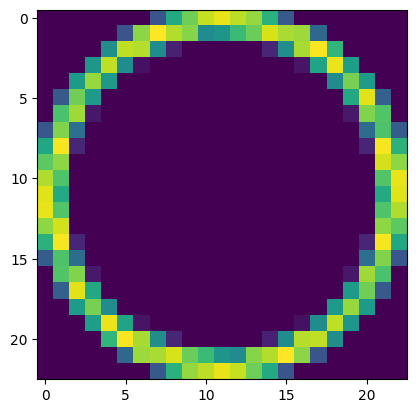

In [14]:
plt.imshow(fft_output_repeated_masked[16])

In [15]:
fft_fingerprint = np.divide(
    np.sum(fft_output_repeated_masked, axis=(1,2)),
    np.sum(use_masks, axis=(1,2))
)

<BarContainer object of 17 artists>

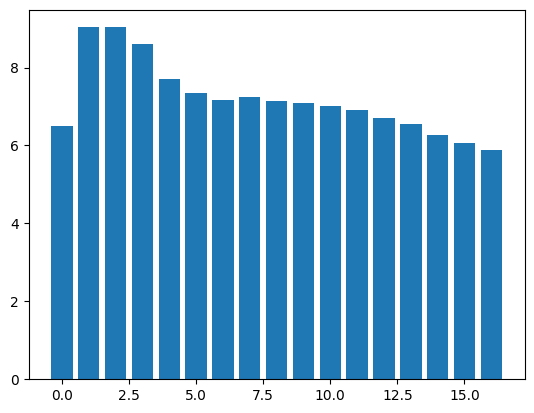

In [16]:
plt.bar(x=range(len(fft_fingerprint)),
        height=fft_fingerprint)

In [72]:
wandering_mask = np.zeros((NUMBER_OF_SAMPLES*3,NUMBER_OF_SAMPLES))

for i in range(NUMBER_OF_SAMPLES):
    wandering_mask[i,i] = 1
    wandering_mask[(NUMBER_OF_SAMPLES*2)-i-1,i:] = 1
    wandering_mask[(NUMBER_OF_SAMPLES*2)+i,:NUMBER_OF_SAMPLES-i] = 1

In [83]:
wandering_mask = np.flip(wandering_mask, axis=1)

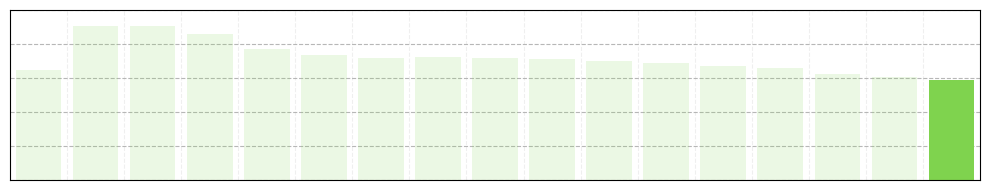

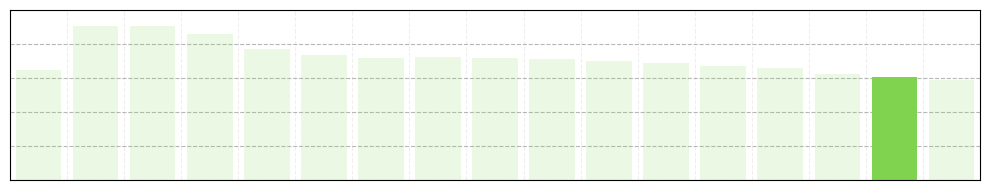

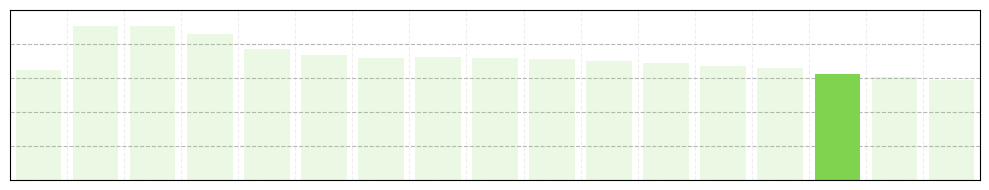

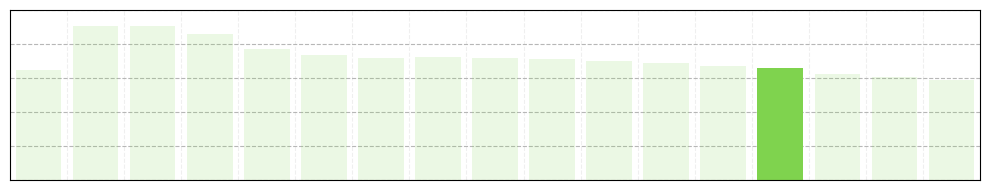

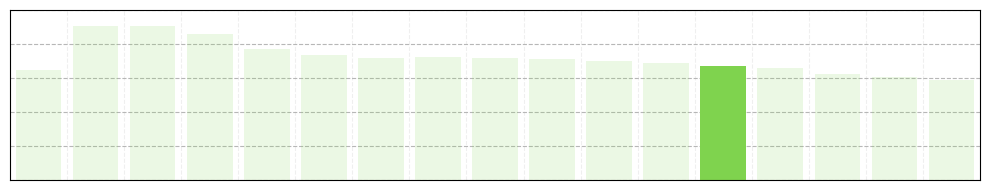

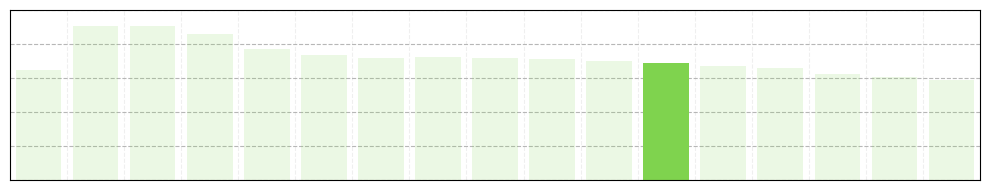

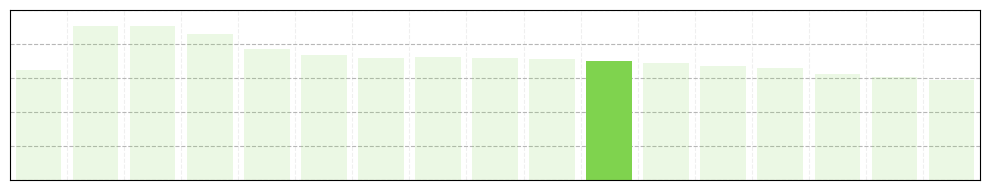

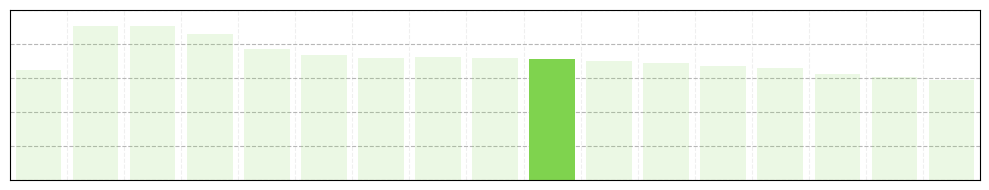

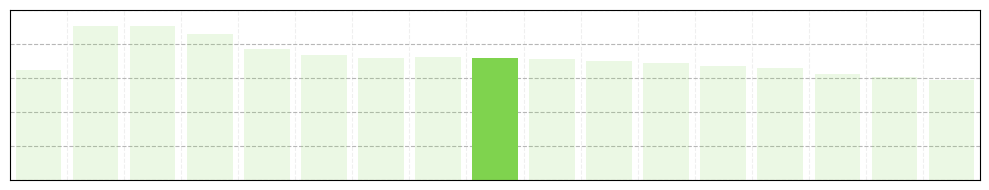

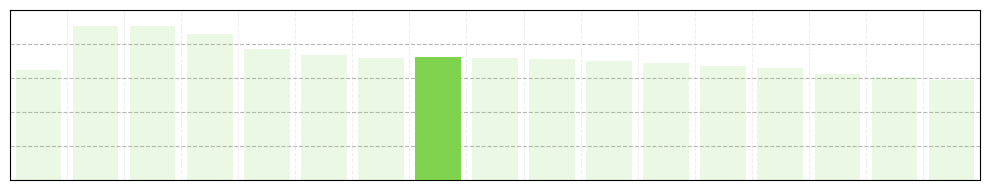

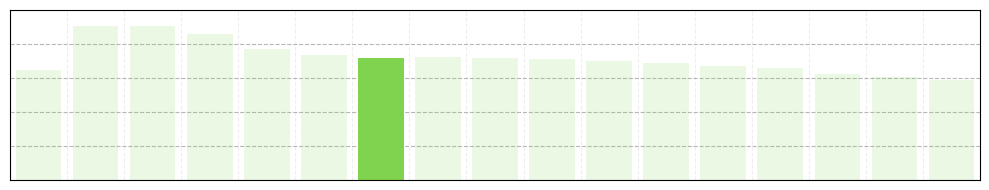

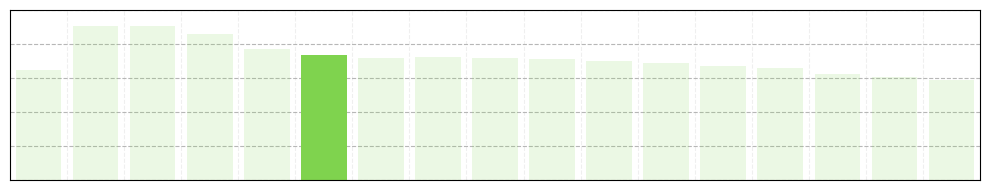

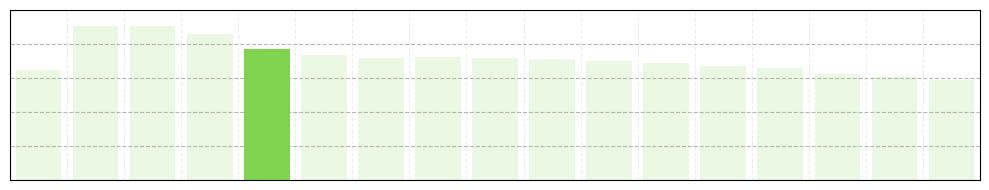

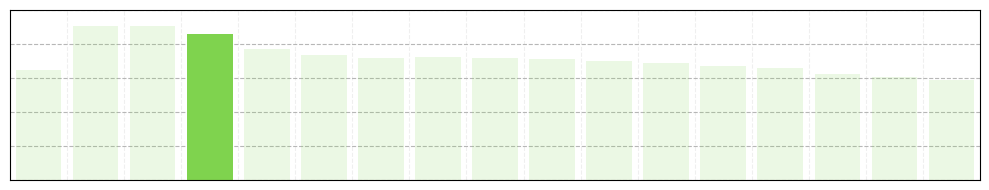

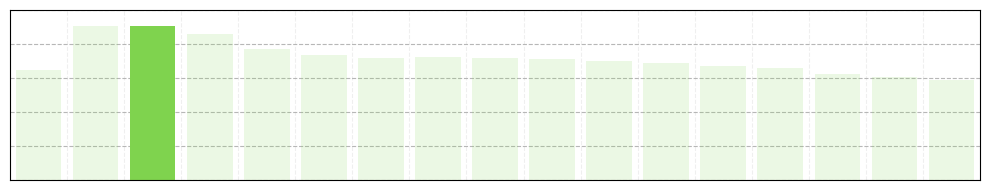

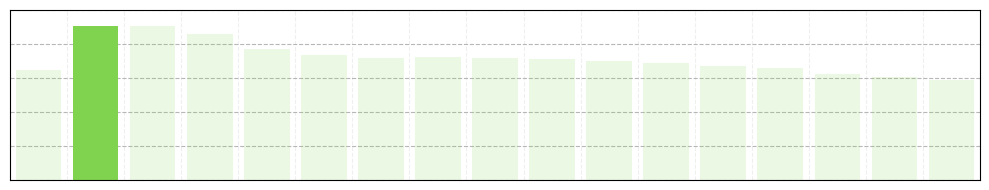

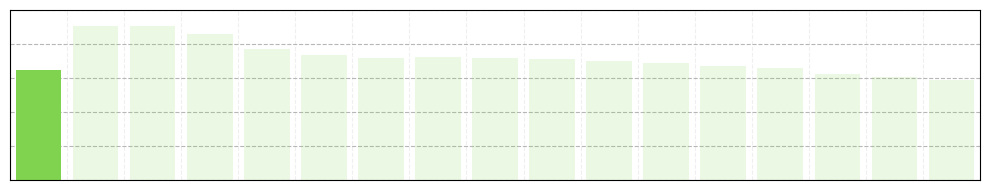

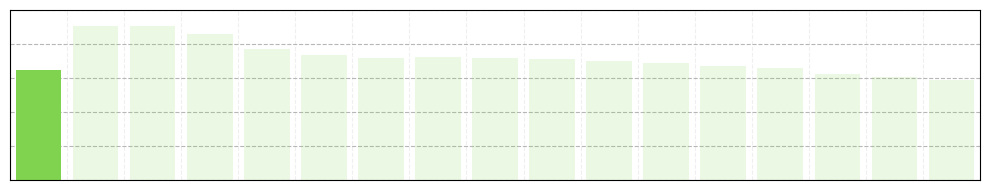

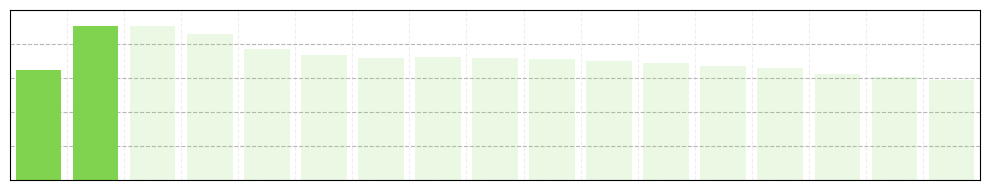

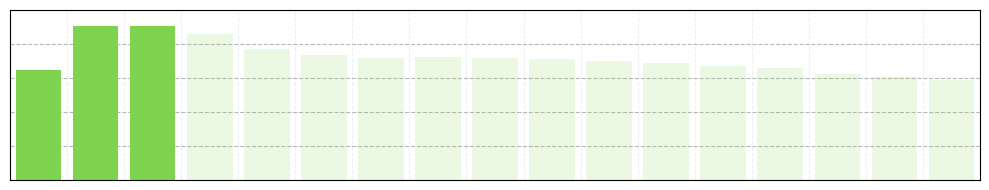

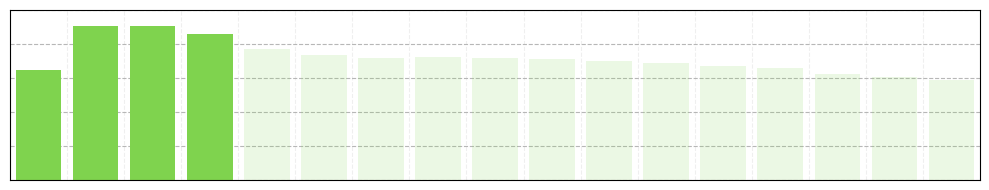

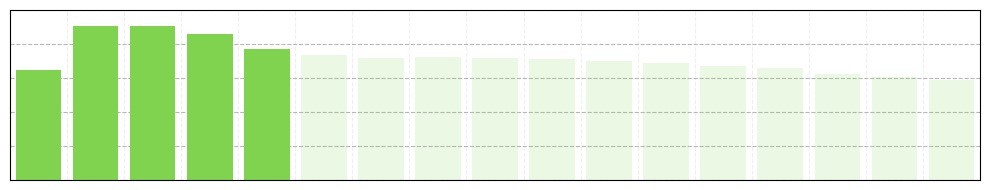

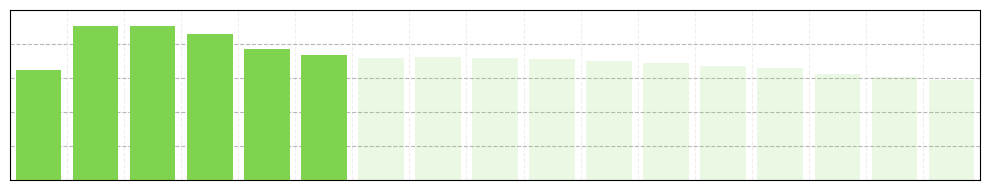

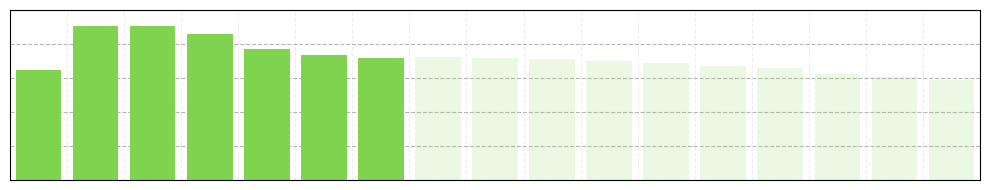

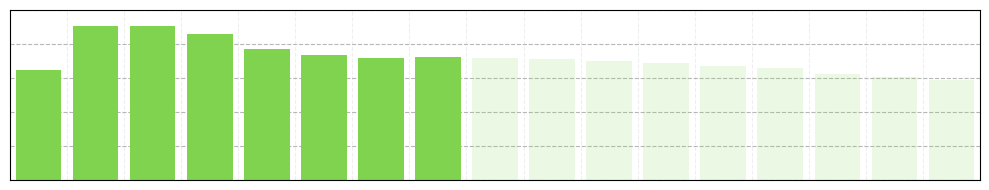

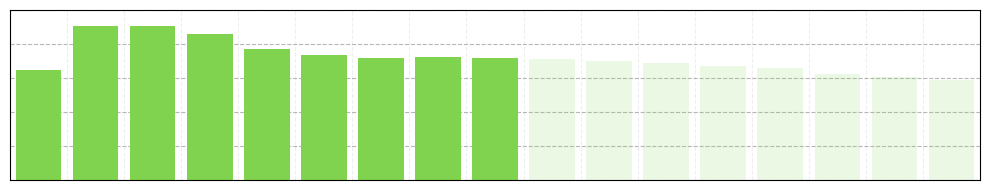

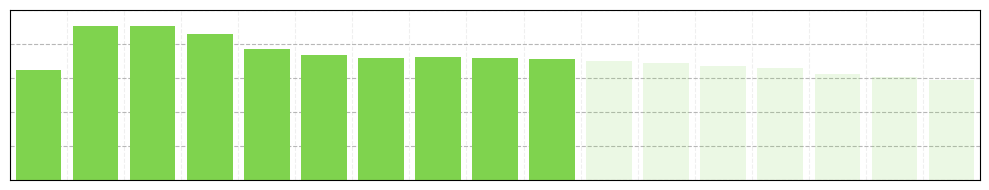

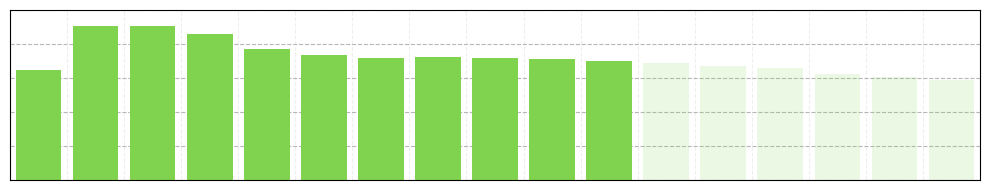

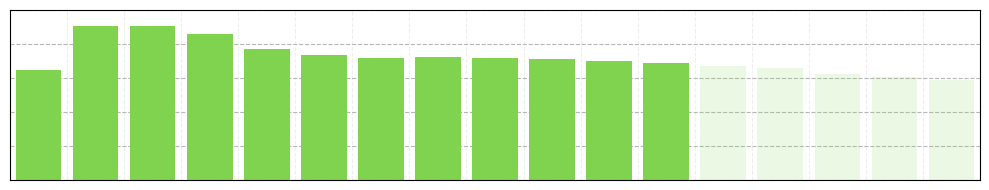

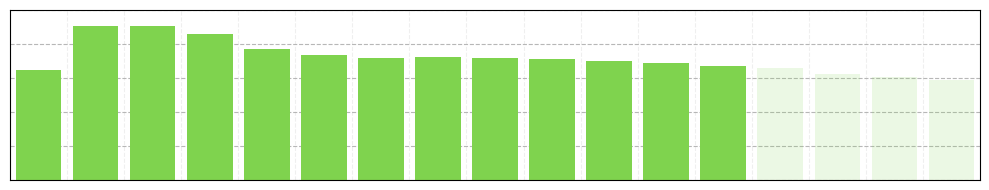

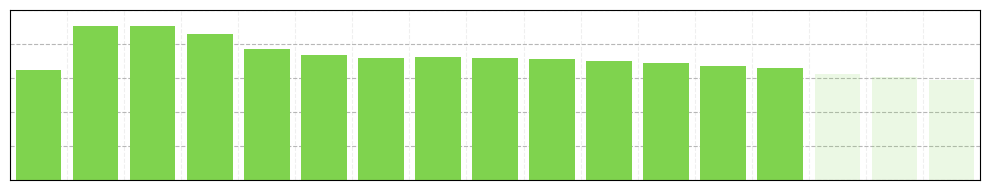

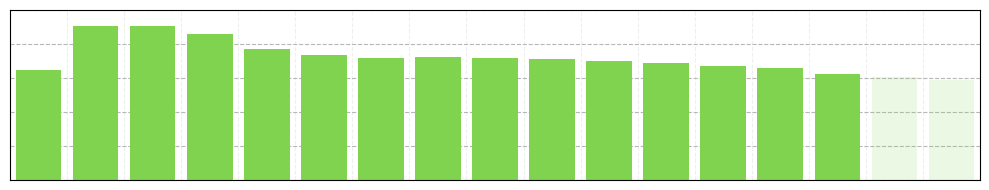

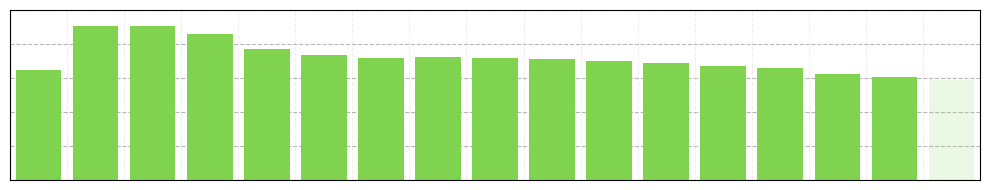

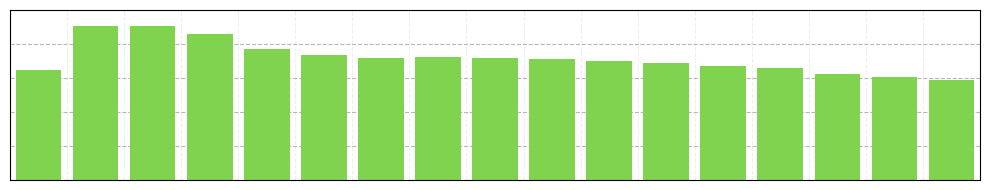

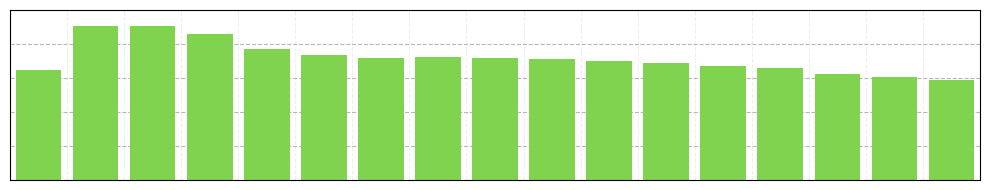

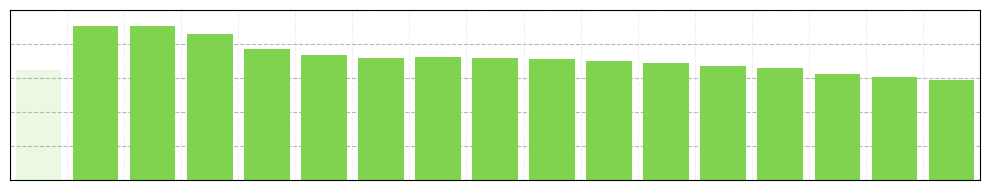

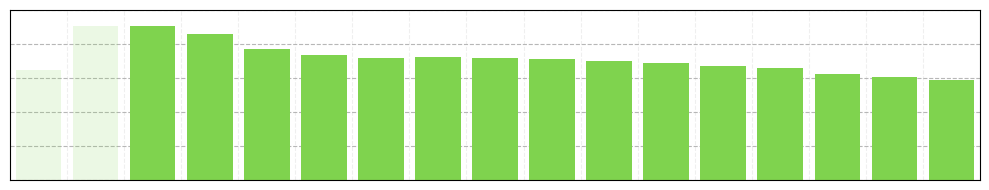

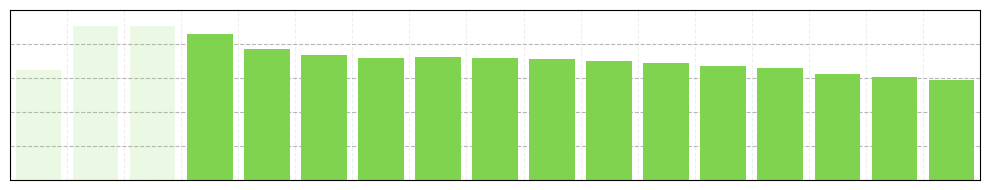

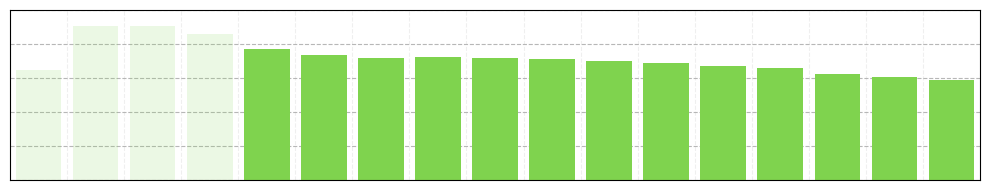

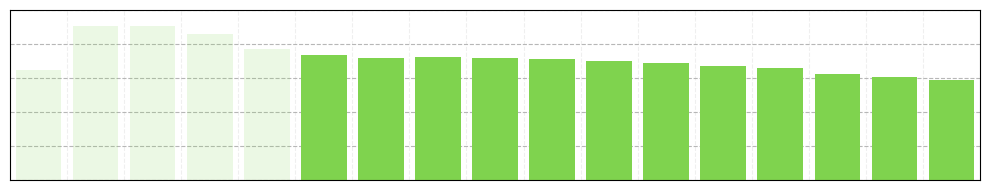

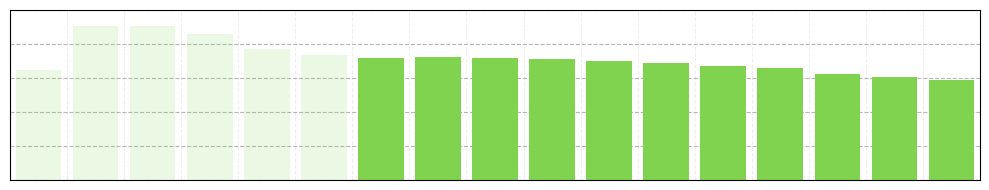

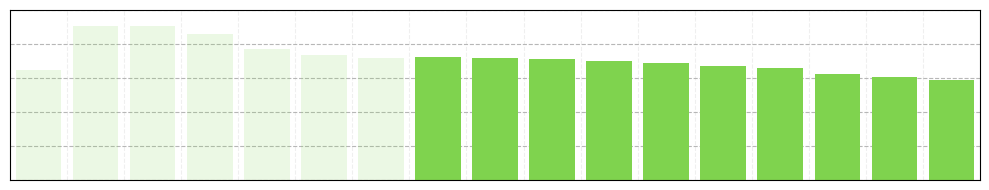

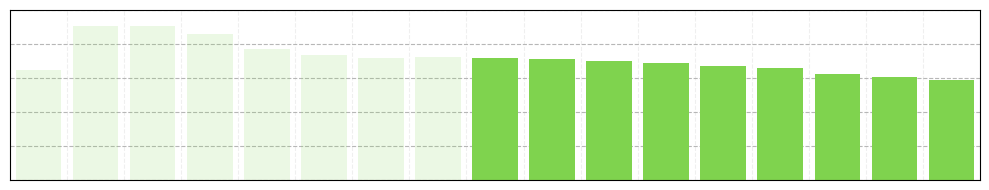

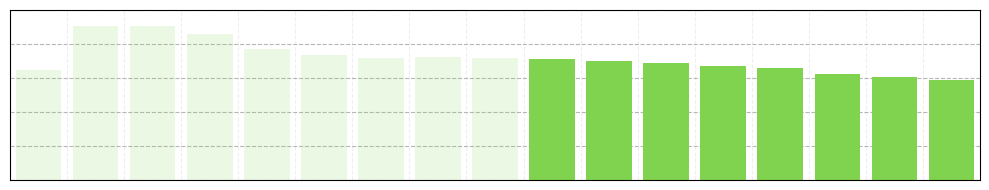

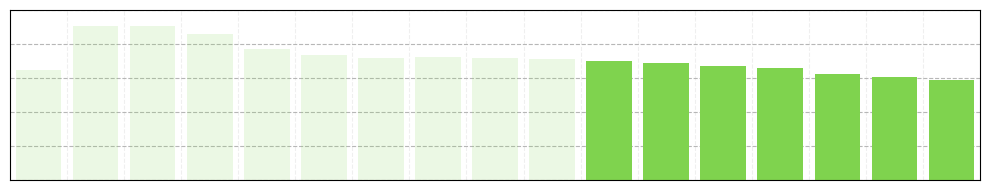

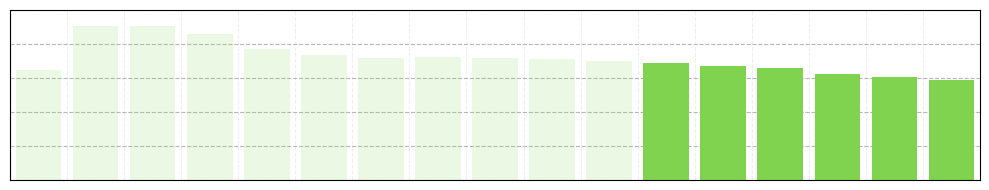

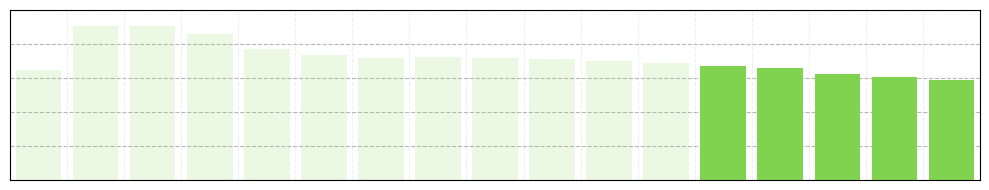

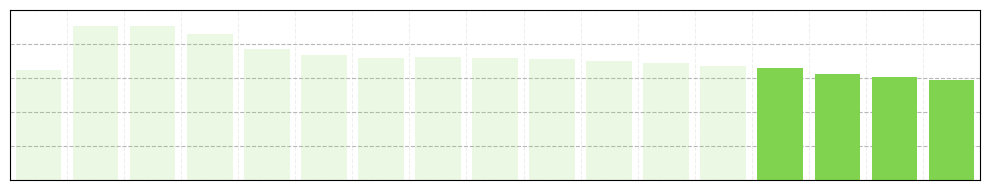

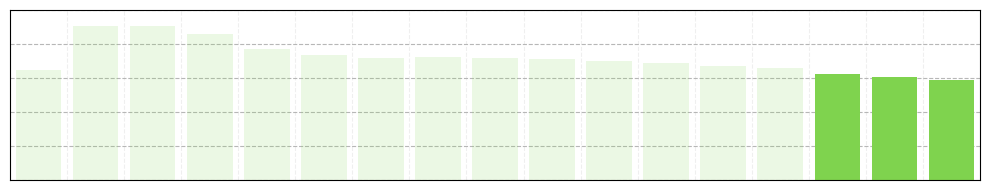

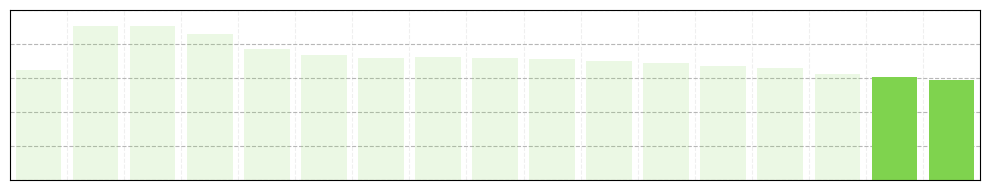

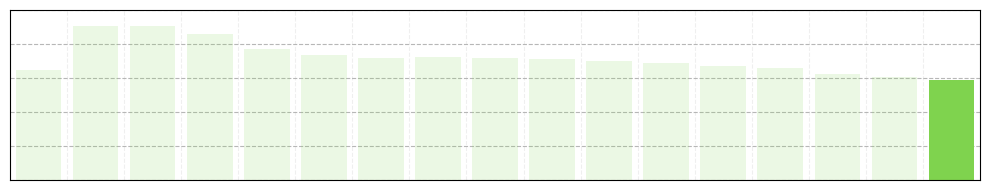

In [84]:


for l in range(len(wandering_mask)):

    shown_amplitudes = fft_fingerprint
    fig, ax = plt.subplots(figsize=(10, 2)
    )

    vmin, vmax = (fft_fingerprint.min(), fft_fingerprint.max())

    heights = shown_amplitudes[0]
    colors = plt.cm.viridis(1-((heights - vmin) / (vmax - vmin)))
    opacity = np.clip(wandering_mask[l] + 0.15, 0, 1)

    barcontainer = ax.bar(np.array(range(NUMBER_OF_SAMPLES))+1, shown_amplitudes, color=colors)
    for n, bar in enumerate(barcontainer):
        bar.set_alpha(opacity[n])


    ax.set_axisbelow(True)
    ax.grid(axis="x", visible=True, alpha=0.2, linestyle="--", which="major")
    ax.grid(axis="y", visible=True, alpha=0.9, linestyle="--", which="major")
    ax.set_yticks([0, 2, 4, 6, 8, 10])
    ax.set_yticklabels(["0","","4","","","10"])
    ax.set_xticks(np.array(range(NUMBER_OF_SAMPLES + 1)) - 0.5)
    ax.set_xticklabels([],)

    ax.set_yticklabels([])
    ax.tick_params(left=False, bottom=False)
    ax.set_xlim([0.5, 0.5 + NUMBER_OF_SAMPLES])   


    fig.tight_layout()
    plt.savefig(f"documentation/fft_magnitudes_animation/fft_pingpong_steps_{l:02d}.png")
    plt.show()

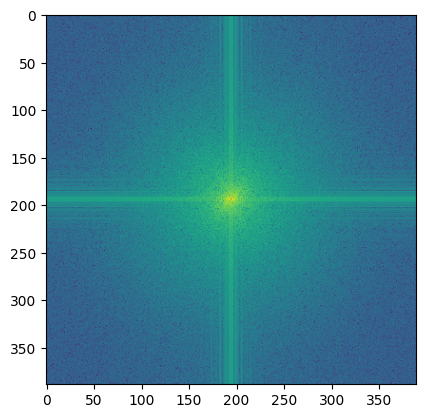

In [19]:
fft_shifted = np.fft.fftshift(fft_output_array, axes=(1,2))
fft_magnitude_display = np.log(np.abs(fft_shifted) + 1)
plt.imshow(fft_magnitude_display[0])

In [13]:
result_images = []

In [14]:
for circle_mask in circle_masks:


    fft_filtered = fft_shifted * circle_mask[np.newaxis, :, :]
    fft_filtered_unshifted = np.fft.ifftshift(fft_filtered, axes=(1,2))
    ifft_input_array = pyfftw.empty_aligned(fft_output_array.shape, dtype="complex64")
    ifft_output_array = pyfftw.empty_aligned(fft_output_array.shape, dtype="complex64")

    ifft_execution_plan = pyfftw.FFTW(
        ifft_input_array,
        ifft_output_array,
        axes=(1,2),
        direction = "FFTW_BACKWARD",
        flags=("FFTW_MEASURE",)
    )

    ifft_input_array[:] = fft_filtered_unshifted
    ifft_execution_plan.execute()

    N = image_pixels.shape[0] * image_pixels.shape[1] 
    result = np.real(ifft_output_array) / N
    result_images.append(np.squeeze(result, axis=0))

In [15]:
result_images_np = np.nan_to_num(np.array(result_images),nan=0)
result_images_np.shape

(170, 389, 389)

In [16]:
def write_ffv1(frames: list[np.ndarray], output: str, fps: int = 24):
    h, w = frames[0].shape
    cmd = [
        "ffmpeg", "-y",
        "-f", "rawvideo",
        "-pix_fmt", "rgb48le",
        "-s", f"{w}x{h}",
        "-r", str(fps),
        "-i", "pipe:",
        "-vcodec", "ffv1",
        "-pix_fmt", "rgb48le",
        "-color_range", "pc",
        "-color_trc", "linear",
        "-colorspace", "rgb",
        "-color_primaries", "bt709",
        output
    ]
    proc = subprocess.Popen(cmd, stdin=subprocess.PIPE)
    for frame in frames:
        frame_rgb = np.stack([frame, frame, frame], axis=-1)
        proc.stdin.write(frame_rgb.astype("<u2").tobytes())
    proc.stdin.close()
    proc.wait()

In [17]:


result_images_std = np.std(result_images_np, axis=(1,2), keepdims=True)
result_images_mean = np.mean(result_images_np, axis=(1,2), keepdims=True)

result_images_std_filtered = gaussian_filter(result_images_std, sigma=5)
result_images_mean_filtered = gaussian_filter(result_images_mean, sigma=10)

In [18]:

result_images_normalized = result_images_np - result_images_mean_filtered

min_result = np.min(result_images_normalized)
max_result = np.max(result_images_normalized)

result_images_normalized -= min_result
result_images_normalized /= max_result - min_result

In [19]:
def to_srgb(data):
    frame_srgb = np.where(data <= 0.0031308,
    12.92 * data,
    1.055 * np.power(data, 1/2.4) - 0.055)

    return frame_srgb

out_anim = to_srgb(result_images_normalized)
#out_anim = np.zeros(shape=(170,300,300))
#out_anim += to_srgb(0.5)

In [20]:

out_anim_uint16 = (np.nan_to_num(out_anim[1:],nan=0) * 255 * 255).astype(np.uint16)

write_ffv1(out_anim_uint16,"output/fft_bandpass/fft_anim_single_italy_reverse.mkv", fps=25)



ffmpeg version 8.1 Copyright (c) 2000-2026 the FFmpeg developers
  built with Apple clang version 17.0.0 (clang-1700.6.4.2)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/8.1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags= --enable-ffplay --enable-gpl --enable-libsvtav1 --enable-libopus --enable-libx264 --enable-libmp3lame --enable-libdav1d --enable-libvpx --enable-libx265 --enable-openssl --enable-videotoolbox --enable-audiotoolbox --enable-neon
  libavutil      60. 26.100 / 60. 26.100
  libavcodec     62. 28.100 / 62. 28.100
  libavformat    62. 12.100 / 62. 12.100
  libavdevice    62.  3.100 / 62.  3.100
  libavfilter    11. 14.100 / 11. 14.100
  libswscale      9.  5.100 /  9.  5.100
  libswresample   6.  3.100 /  6.  3.100
Input #0, rawvideo, from 'pipe:':
  Duration: N/A, start: 0.000000, bitrate: 181585 kb/s
  Stream #0:0: Video: rawvideo (RGB0 / 0x30424752), rgb48le, 389x389, 181585 kb/s, 25 tbr, 25 tbn
Stream mapping:
  Stre

In [21]:
def geschummerte_darstellung(array):
    shifted = np.roll(array,1,axis=0)
    shifted = np.roll(shifted,1,axis=1)
    visuals = array - shifted
    plt.imshow(visuals, cmap="grey", vmax=10, vmin=-10)
    plt.show()

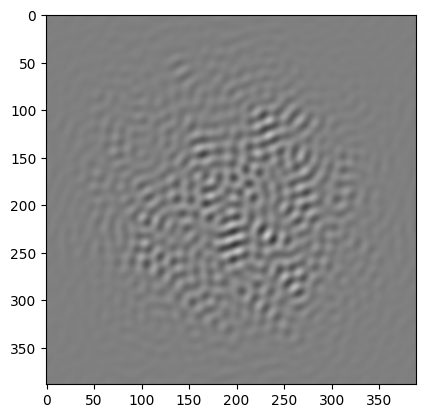

In [22]:
geschummerte_darstellung(result_images_np[70])

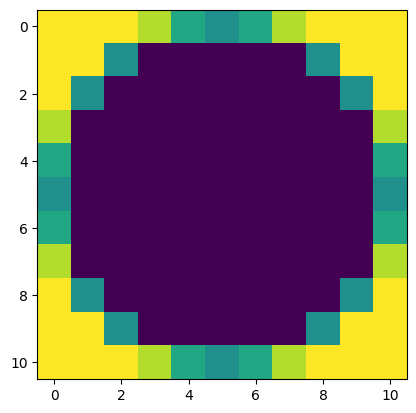

In [23]:
plt.imshow(common.CircleImage(11,11,5))

In [24]:
from scipy.ndimage import convolve
from scipy.signal import fftconvolve


def filter_with_circle(input, circle_filter = None,radius=10):

    radius = int(radius)

    use_diameter = (2*radius) + 1

    if circle_filter is None:
        circle_filter = common.CircleImage(use_diameter,use_diameter,radius, inverted=True)


    use_pad = max(circle_filter.shape*2)
    
    input_padded = np.pad(input, use_pad, mode="constant", constant_values=0)
    gueltigkeit_padded = np.pad(np.ones_like(input), use_pad, mode="constant", constant_values=0)


    zaehler = fftconvolve(input_padded * gueltigkeit_padded, circle_filter, mode="same")
    nenner  = fftconvolve(gueltigkeit_padded, circle_filter, mode="same")

    ergebnis_padded = zaehler / np.maximum(nenner, 1e-6)
    ergebnis = ergebnis_padded[use_pad:-use_pad, use_pad:-use_pad]


    plt.imshow(ergebnis)
    return ergebnis

    

In [25]:
import numpy as np
import numpy as np
from scipy.signal import fftconvolve


def convolve_images_with_masks(images, masks, nan_aware=True):
    """
    Faltet N Bilder mit M Masken.
    images : (N, H, W), darf NaN enthalten
    masks  : Liste von Masken, dürfen unterschiedlich groß sein
    return : (N, M, H, W)
    """
    N, H, W = images.shape
    M = len(masks)
    result = np.zeros((N, M, H, W), dtype=np.float32)

    if nan_aware:
        valid = (~np.isnan(images)).astype(np.float32)            # (N, H, W)
        clean = np.where(np.isnan(images), 0.0, images).astype(np.float32)
    else:
        clean = images.astype(np.float32)

    for i, mask in enumerate(masks):
        k = mask.astype(np.float32)[None, :, :]                   # (1, kh, kw)

        # mode="same" zentriert selbst, axes faltet pro Bild
        num = fftconvolve(clean, k, mode="same", axes=(-2, -1))   # (N, H, W)

        if nan_aware:
            den = fftconvolve(valid, k, mode="same", axes=(-2, -1))
            result[:, i] = num / np.maximum(den, 1e-6)
        else:
            result[:, i] = num

    return result

In [26]:
fat_circle_masks_outer = common.CircleImageSeries(int(image_pixels.shape[0]*2.828),
                                                  int(image_pixels.shape[1]*2.828)
                                                  ,17,1,True)
fat_circle_masks_inner = common.CircleImageSeries(int(image_pixels.shape[0]*2.828),
                                                  int(image_pixels.shape[1]*2.828)
                                                  ,17,1,False)

AttributeError: module 'common' has no attribute 'CircleImageSeries'

In [ ]:
testimages_outer = convolve_images_with_masks(image_pixels[None,:,:,],fat_circle_masks_outer, nan_aware=True)
testimages_inner = convolve_images_with_masks(image_pixels[None,:,:,],fat_circle_masks_inner, nan_aware=True)

In [ ]:
plt.imshow(fat_circle_masks_inner[0])

In [ ]:
testimages_difference = testimages_inner[0] - testimages_outer[0]

In [ ]:
plt.imshow(testimages_difference[0])

In [ ]:
for img in testimages_difference:
    geschummerte_darstellung(img)

In [ ]:
plt.imshow(testimages_difference[16])

In [ ]:
cs = np.sum(testimages_difference, axis=0)

In [ ]:
plt.imshow(image_pixels)

In [ ]:
plt.imshow(cs)

In [ ]:
csb = np.roll(cs, -1, axis=0)
csb = np.roll(csb, -1, axis=1)
plt.imshow(csb-image_pixels)
np.std(csb-image_pixels)

In [ ]:
acht = np.linspace(8,8,4)

In [ ]:
np.pad(acht, 4, mode="constant", constant_values=0)[4:-4]

In [ ]:
def diameter_series(end, steps, finesteps=None):
    # "steps" Schritte inkl. 1 und "end"

    if finesteps is None: finesteps = steps

    factor = 10 **( (np.log10(end)) / (steps-1))

    series = np.logspace(0, np.log10(end), finesteps)

    return (series, factor)

diameter_series(300,5,16)

In [ ]:
finesteps = 30

diameters_first, factor_first = diameter_series(
    np.linalg.norm(image_pixels.shape,2) / 2, 17, finesteps
)
root_factor = np.sqrt(factor_first)
diameters_outer = diameters_first * root_factor
diameters_inner = diameters_first / root_factor


circle_masks_outer = []
circle_masks_inner = []

for i in range(finesteps):
    circle_masks_outer.append(
        common.CircleImage(
            image_pixels.shape[0]*2,
            image_pixels.shape[1]*2,
            diameters_outer[i],
            inverted=True,
        )
    )

    circle_masks_inner.append(
        common.CircleImage(
            image_pixels.shape[0]*2,
            image_pixels.shape[1]*2,
            diameters_inner[i],
            inverted=True,
        )
    )

pictures_outer = np.squeeze(
    convolve_images_with_masks(
        image_pixels[
            None,
            :,
            :,
        ],
        circle_masks_outer,
        nan_aware=True,
    ),
    axis=0,
)


pictures_inner =  np.squeeze(
    convolve_images_with_masks(
        image_pixels[
            None,
            :,
            :,
        ],
        circle_masks_inner,
        nan_aware=True,
    ),
    axis=0,
)



In [ ]:
pictures_combined_a = pictures_inner - pictures_outer

for pic in pictures_combined_a:
    plt.imshow(pic)
    plt.show()

In [ ]:
pictures_combined_b = pictures_inner - pictures_outer[-1] 

for pic in pictures_combined_b[::-1]:
    plt.imshow(pic)
    plt.show()

In [ ]:
pictures_combined_c =  pictures_inner[0] - pictures_outer[::-1] 

for pic in pictures_combined_c:
    plt.imshow(pic)
    plt.show()

In [ ]:
pictures_combined_all = np.concat((pictures_combined_a,pictures_combined_b[::-1],pictures_combined_c), axis = 0)
pictures_combined_all = pictures_combined_all[1:]

In [ ]:


pictures_combined_all_mean = np.mean(pictures_combined_all, axis=(1,2), keepdims=True)
pictures_combined_all_std = np.std(pictures_combined_all, axis=(1,2), keepdims=True)

pictures_combined_all_processed = pictures_combined_all - pictures_combined_all_mean
pictures_combined_all_processed = pictures_combined_all_processed / pictures_combined_all_std

pictures_combined_all_processed_mean = np.mean(pictures_combined_all_processed, axis=(1,2), keepdims=True)
pictures_combined_all_processed_std = np.std(pictures_combined_all_processed, axis=(1,2), keepdims=True)

pictures_combined_all_processed_mean_filtered = gaussian_filter(pictures_combined_all_processed_mean, mode="nearest", sigma=2)
pictures_combined_all_processed_std_filtered = gaussian_filter(pictures_combined_all_processed_std, mode="nearest", sigma=2)

pictures_combined_all_processed = pictures_combined_all_processed - pictures_combined_all_processed_mean_filtered
pictures_combined_all_processed = pictures_combined_all_processed / pictures_combined_all_processed_std_filtered

In [ ]:
for pic in pictures_combined_all_processed:
    plt.imshow(pic)
    plt.show()

In [ ]:
np.mean(pictures_combined_all_processed, axis=(1,2))

In [ ]:
pictures_combined_all_range = np.max(pictures_combined_all) - np.min(pictures_combined_all)
video_data = (pictures_combined_all - np.min(pictures_combined_all)) / pictures_combined_all_range

video_data = (video_data * 255 * 255).astype(np.uint16)

write_ffv1(video_data,"output/video.mkv",25)